In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import squarify
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

df_informe_final = pd.read_csv('../datos/datos_informe_final.csv')
print(f'Columnas: {list(df_informe_final.columns)}')

Columnas: ['Genero', 'Ciudad', 'Fecha de Nacimiento', 'Nota Razonamiento Cuantitativo', 'Nota Comprension Lectora', 'Nota Ingles', 'Edad', 'Region', 'Rango Edad', 'Mejor Area']


# Informe Final

## 1. ¿Quiénes son los aspirantes?

#### Por Rango de Edad

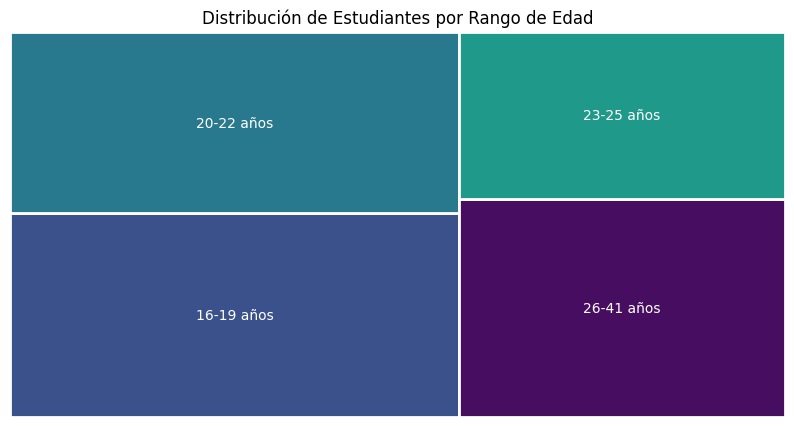

In [2]:
rg_edad = df_informe_final['Rango Edad'].value_counts()
sizes = rg_edad.values
labels = rg_edad.index
plt.figure(figsize=(10, 5))
squarify.plot(
    sizes=sizes,
    label=labels,
    edgecolor='white',
    linewidth=2,
    text_kwargs={'color': 'white'} 
)
plt.axis('off')
plt.title('Distribución de Estudiantes por Rango de Edad')
plt.show()

La población de aspirantes es mayoritariamente joven: más de la mitad tiene 22 años o menos.

Un 75% de los aspirantes, en general, tiene 25 años o menos, lo que recalca la conclusión anterior.

Pese a haber un lapso mayor en el rango de 26 a 41 años, el de mayor edad, este solo concentra aproximadamente un cuarto de la población.

---
#### Por Género

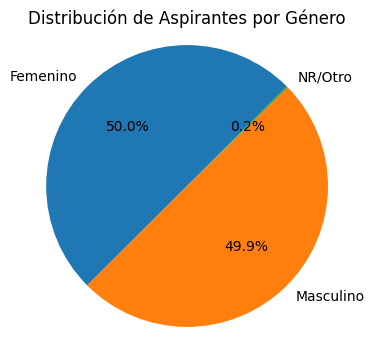

In [3]:
conteo_genero = df_informe_final['Genero'].value_counts()
labels = conteo_genero.index
sizes = conteo_genero.values
plt.figure(figsize=(4, 4))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=45
)
plt.title('Distribución de Aspirantes por Género')
plt.axis('equal')
plt.show()

La distribución por sexo es prácticamente equilibrada entre mujeres (femenino) y hombres (masculino). 

Existe un porcentaje mínimo de aspirantes que no se asocian a una identidad de género no binaria.

---
#### Por Ciudad y Región de Origen

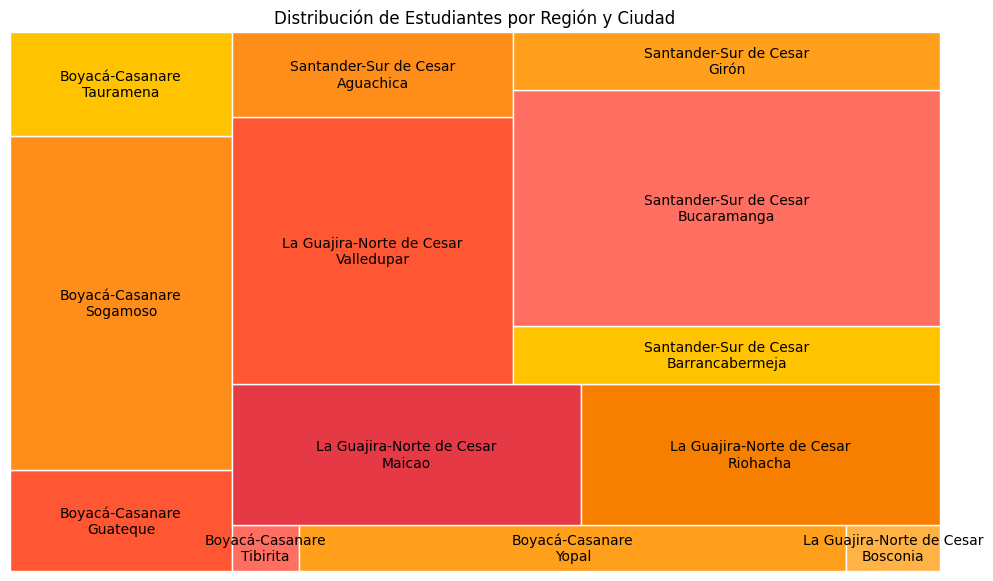

In [4]:
cd_rg = df_informe_final.groupby(["Region", "Ciudad"]).size().reset_index(name='count')
colores = ['#FF5733', '#FF8D1A', '#FFC300', '#FF6F61', '#FF9F1C',
            '#FFB347', '#E63946', '#F77F00']
plt.figure(figsize=(12, 7))
squarify.plot(
    sizes=cd_rg['count'],
    label=cd_rg['Region'] + "\n" + cd_rg['Ciudad'],
    color=colores,
    edgecolor='white',
)
plt.axis('off')
plt.title('Distribución de Estudiantes por Región y Ciudad')
plt.show()

Existe una alta concentración geográfica de los aprendices en la ciudad de Bucaramanga, y en la región Santander-Sur de Cesar. Son considerables también las poblaciones de las ciudades de Valledupar, Riohacha y Maicao, en el norte del país. Ciudades de los departamentos de Boyacá y Casanare como Sogamoso y Yopal, también presentan una porción considerable de aprendices. 

Todas estas ciudades y regiones, a su vez, están aglutinadas en departamentos distribuidos por el nororiente de Colombia.

---

Insight: Los aspirantes comparten características demográficas relativamente homogéneas, aunque con concentración en regiones definidas.

---
---

## 2. ¿Las diferencias demográficas afectan el rendimiento?

#### Por Género

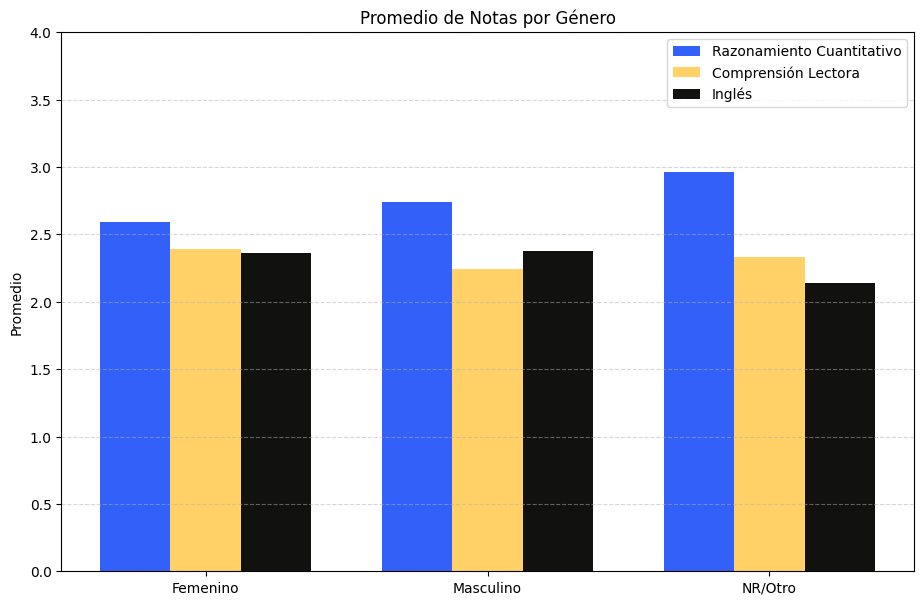

In [5]:
generos = ['Femenino', 'Masculino', 'NR/Otro']

#Datos tomados del notebook 02_analisis_exploratorio
raz = [2.59, 2.74, 2.96]
lec = [2.39, 2.24, 2.33]
ing = [2.36, 2.38, 2.14] 

x = np.arange(len(generos))
width = 0.25
plt.figure(figsize=(11, 7))
plt.bar(x - width, raz, width, label='Razonamiento Cuantitativo', color="#3260F8")
plt.bar(x, lec, width, label='Comprensión Lectora', color='#FFD166')
plt.bar(x + width, ing, width, label='Inglés', color="#111110")
plt.xticks(x, generos)
plt.ylabel('Promedio')
plt.title('Promedio de Notas por Género')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0.0, 4.0)
plt.show()

Los hombres presentan mejor desempeño en Razonamiento Cuantitativo y las mujeres tienen mejor desempeño en Comprensión Lectora; sin embargo, las diferencias, en ambos escenarios, son mínimas. En Inglés, ambos géneros tienen desempeño similar.

En mujeres y hombres, ninguna área evaluada superó el umbral mínimo para aprobar, de 3.

Teniendo en cuenta el reducido tamaño muestral de la población "NR/Otro", no es posible hacer inferencias sólidas de él.

---
#### Por Rango de Edad

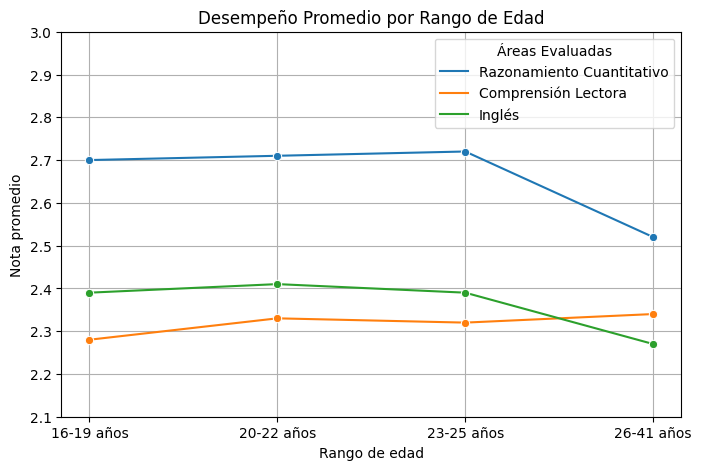

In [6]:
#Datos tomados del notebook 02_analisis_exploratorio
datos_rangos_ed = {
    "Rango Edad": ["16-19 años", "20-22 años", "23-25 años", "26-41 años"],
    "Razonamiento Cuantitativo": [2.70, 2.71, 2.72, 2.52],
    "Comprensión Lectora": [2.28, 2.33, 2.32, 2.34],
    "Inglés": [2.39, 2.41, 2.39, 2.27]
}

df_auxiliar = pd.DataFrame(datos_rangos_ed)

df_dg_lineal = df_auxiliar.melt(id_vars="Rango Edad", 
                    var_name="Áreas Evaluadas", 
                    value_name="Nota Promedio")

plt.figure(figsize=(8,5))
sns.lineplot(data=df_dg_lineal, 
             x="Rango Edad", 
             y="Nota Promedio", 
             hue="Áreas Evaluadas", 
             marker="o")
plt.title("Desempeño Promedio por Rango de Edad")
plt.ylabel("Nota promedio")
plt.xlabel("Rango de edad")
plt.ylim(2.1, 3.0)
plt.grid(True)
plt.show()

El desempeño promedio es relativamente homogéneo entre rangos de edad.

Razonamiento Cuantitativo destaca como el área más fuerte en la mayoría de los estudiantes.

El desempeño en Razonamiento Cuantitativo e Inglés se mantiene estable en edades tempranas, y presenta una leve caída en los aspirantes de mayor edad, más marcada en el primera área evaluada que en la segunda.

El desempeño en Comprensión Lectora es el más bajo en todos los rangos de edad, excepto en el de los aspirantes mayores.

Con todo, hay que tener presente que, a nivel general, el desempeño en todas las áreas evaluadas es bajo.

---
#### Por Región

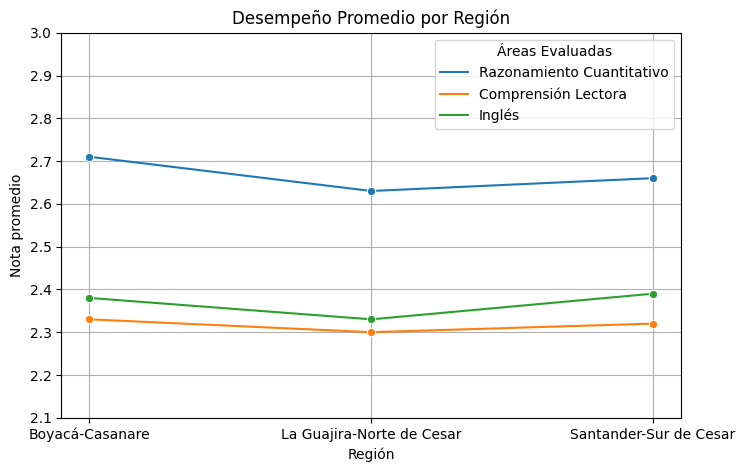

In [7]:
datos_regiones = {
    "Region": ["Boyacá-Casanare", "La Guajira-Norte de Cesar", "Santander-Sur de Cesar"],
    "Razonamiento Cuantitativo": [2.71, 2.63, 2.66],
    "Comprensión Lectora": [2.33, 2.30, 2.32],
    "Inglés": [2.38, 2.33, 2.39]
}

df_auxiliar = pd.DataFrame(datos_regiones)

df_dg_lineal = df_auxiliar.melt(id_vars="Region", 
                    var_name="Áreas Evaluadas", 
                    value_name="Nota Promedio")

plt.figure(figsize=(8,5))
sns.lineplot(data=df_dg_lineal, 
             x="Region", 
             y="Nota Promedio", 
             hue="Áreas Evaluadas", 
             marker="o")
plt.title("Desempeño Promedio por Región")
plt.ylabel("Nota promedio")
plt.xlabel("Región")
plt.ylim(2.1, 3.0)
plt.grid(True)
plt.show()

Las diferencias regionales en desempeño son marginales.

La región La Guajira-Norte de Cesar está consistentemente un poco por debajo en las tres áreas.

Los estudiantes tienden a obtener mejores resultados en Razonamiento Cuantitativo que en Comprensión Lectora, con Inglés en un nivel intermedio. 

Esto sugiere que las brechas están más asociadas al tipo de competencia evaluada que al plano regional.

---
#### Por Ciudad (Las 5 con más aspirantes)

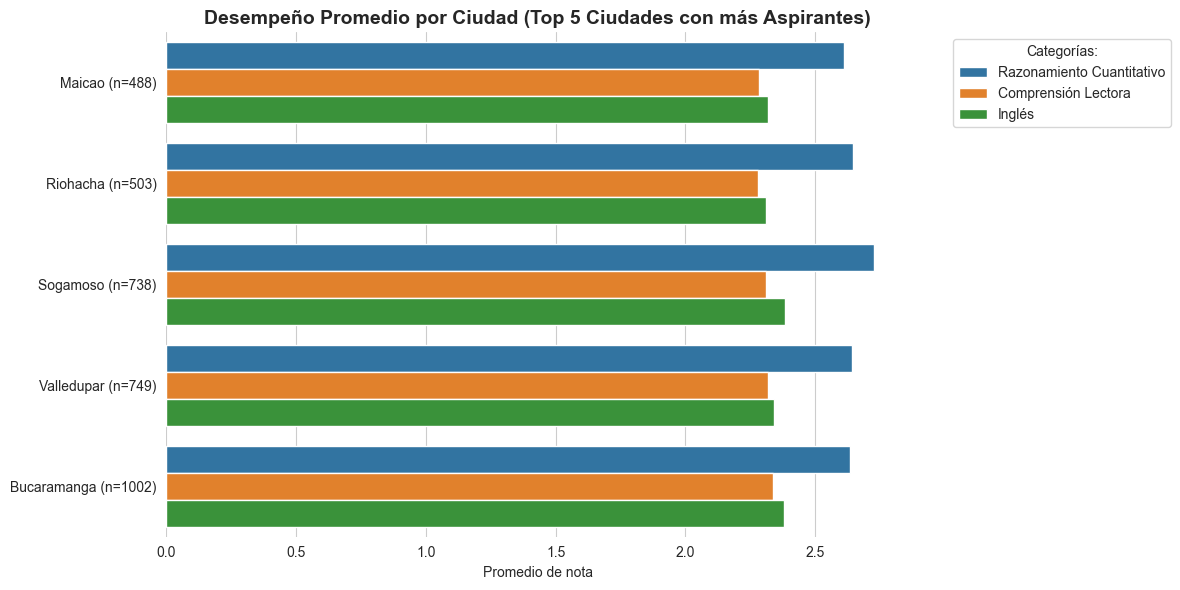

In [9]:
df_ciudad = (
    df_informe_final
    .groupby('Ciudad')
    .agg(
        n=('Ciudad', 'size'),
        rq=('Nota Razonamiento Cuantitativo', 'mean'),
        cl=('Nota Comprension Lectora', 'mean'),
        ing=('Nota Ingles', 'mean')
    )
    .reset_index()
)

df_ciudad = df_ciudad.sort_values('n', ascending=False).head(5)
df_ciudad['Ciudad_label'] = df_ciudad['Ciudad'] + ' (n=' + df_ciudad['n'].astype(str) + ')'
df_ciudad = df_ciudad.sort_values('n', ascending=True)

df_plot = df_ciudad.melt(
    id_vars=['Ciudad_label'],
    value_vars=['rq', 'cl', 'ing'],
    var_name='Área',
    value_name='Promedio'
)

df_plot['Área'] = df_plot['Área'].replace({
    'rq': 'Razonamiento Cuantitativo',
    'cl': 'Comprensión Lectora',
    'ing': 'Inglés'
})

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_plot,
    x='Promedio',
    y='Ciudad_label',
    hue='Área'
)

plt.title('Desempeño Promedio por Ciudad (Top 5 Ciudades con más Aspirantes)', fontsize=14, weight='bold')
plt.xlabel('Promedio de nota')
plt.ylabel('')
plt.legend(title='Área', frameon=False)

sns.despine(left=True, bottom=True)
plt.legend(
    title='Categorías:',
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

El patrón de Razonamiento Cuantitativo siendo la mejor área se evidencia, también, al analizar los resultados por ciudad. El desempeño en Inglés y Comprensión Lectora es similar en cada caso. 
En cualquier caso, las diferencias no son amplias.

---
Insight: Las diferencias por sexo, edad y lugar de origen existen, pero son demasiado pequeñas para explicar el desempeño general.

---
---

## 3. El bajo desempeño no depende de la demografía. ¿Dónde está realmente el problema?

El bajo desempeño no está determinado de forma significativa por sexo, edad o región. Sí hay diferencias, pero no son significativas; en algunos casos, incluso, son marginales.

El problema es estructural. Las debilidades son compartidas por la mayoría de los aspirantes.

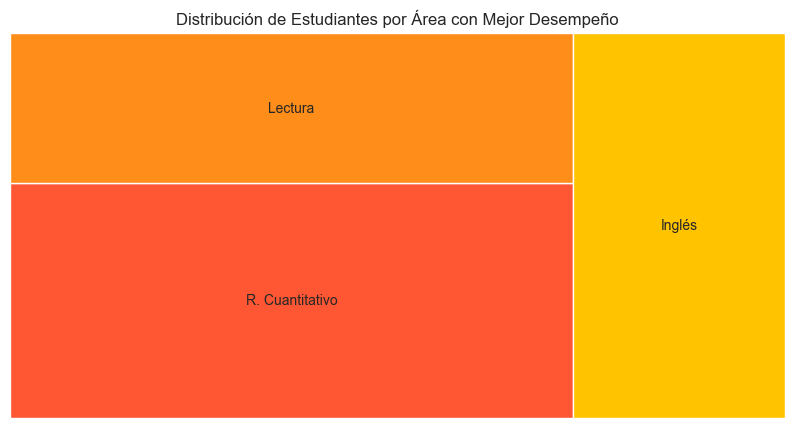

In [9]:
ciudades = df_informe_final['Mejor Area'].value_counts()
sizes = ciudades.values
labels = ciudades.index
colores = ['#FF5733', '#FF8D1A', '#FFC300', '#FF6F61', '#FF9F1C',
            '#FFB347', '#E63946', '#F77F00']
plt.figure(figsize=(10, 5))
squarify.plot(
    sizes=sizes,
    label=labels,
    color=colores,
    edgecolor='white',
)
plt.axis('off')
plt.title('Distribución de Estudiantes por Área con Mejor Desempeño')
plt.show()

A la mayoría de los aspirantes le va mejor en Razonamiento Cuantitativo que en las otras dos áreas evaliuadas, si bien hay porción considerable que tuvo su mejor desempeño en Inglés, y otra en Comprensión Lectora.

## 4. El perfil del aspirante típico

Es una persona joven de entre 19 y 22 años, con igual probabilidad de ser hombre o mujer, y proviene de una ciudad grande o intermedia del noroccidente del país. Tiene un desempeño aceptable en Razonamiento Cuantitativo, pero le cuesta destacarse en Comprensión Lectora e Inglés.